In [ ]:
from feature_engineering import build_and_save

COMBINED = build_and_save(
    input_csv='SMILES_Inchikey_IR_LD50_RAW.csv',
    output_csv='Broaden_Group_RAW.csv',
)

In [1]:
##SPLIT
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

COMBINED = pd.read_csv("Broaden_Group_RAW.csv")

ir_cols = [c for c in COMBINED if c.startswith(("f","band_"))]
fp_cols = [c for c in COMBINED if c.startswith("ecfp_")]

IR = COMBINED[ir_cols].apply(pd.to_numeric, errors="coerce").to_numpy(np.float64)
FP = COMBINED[fp_cols].to_numpy(np.float64)
y  = pd.to_numeric(COMBINED["LD50"], errors="coerce").to_numpy(np.float64)

mask = np.isfinite(y) & np.isfinite(IR).all(1) & np.isfinite(FP).all(1)
IR, FP, y = IR[mask], FP[mask], y[mask]

# Split 70/15/15
idx = np.arange(len(y))
tr, te = train_test_split(idx, test_size=0.15, random_state=42)
tr, va = train_test_split(tr, test_size=0.15/0.85, random_state=42)

IR_tr, IR_val, IR_te = IR[tr], IR[va], IR[te]
FP_tr, FP_val, FP_te = FP[tr], FP[va], FP[te]
y_tr, y_val, y_te    = y[tr], y[va], y[te]


In [ ]:
#==Analysis on ecfp===

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances

# --- 1) Correlation of each ECFP feature with LD50 ---
corrs = []
for i in range(FP.shape[1]):
    if np.std(FP[:, i]) == 0:  
        corrs.append(0.0)
    else:
        corrs.append(np.corrcoef(FP[:, i], y)[0, 1])
corrs = np.array(corrs)

print("Correlation with LD50 across ECFP bits:")
print("  min:", np.nanmin(corrs))
print("  max:", np.nanmax(corrs))
print("  mean:", np.nanmean(corrs))
print("  non-constant bits:", np.sum(corrs != 0))

Correlation with LD50 across ECFP bits:
  min: -0.3313816179756919
  max: 0.12083841751316593
  mean: -0.010935938513319076
  non-constant bits: 2048


Average fraction of '1' bits per molecule: 0.0137


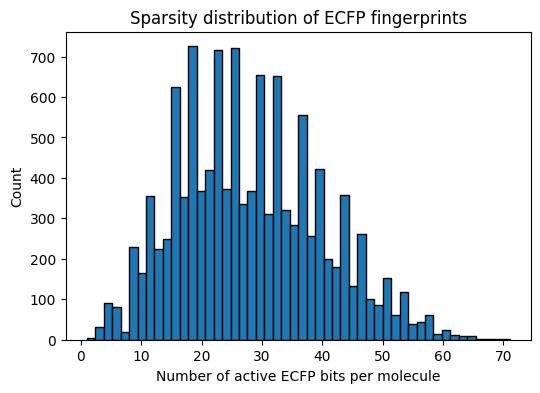

In [4]:
# --- 2) Sparsity check ---
density = FP.mean()
print(f"Average fraction of '1' bits per molecule: {density:.4f}")

plt.figure(figsize=(6,4))
plt.hist(FP.sum(axis=1), bins=50, edgecolor="k")
plt.xlabel("Number of active ECFP bits per molecule")
plt.ylabel("Count")
plt.title("Sparsity distribution of ECFP fingerprints")
plt.show()

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.004s...
[t-SNE] Computed neighbors for 2000 samples in 0.357s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 1.517359
[t-SNE] KL divergence after 250 iterations with early exaggeration: 75.803139
[t-SNE] KL divergence after 1000 iterations: 2.014299


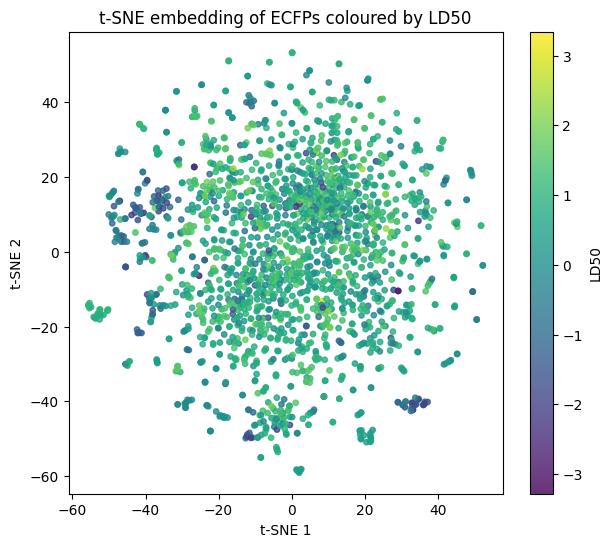

In [7]:
from sklearn.manifold import TSNE

# --- 3) 2D t-SNE embedding of ECFPs coloured by LD50 ---
n_sample = min(2000, FP.shape[0])   
idx = np.random.choice(FP.shape[0], n_sample, replace=False)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    max_iter=1000,   
    verbose=1
)
FP_embedded = tsne.fit_transform(FP[idx])

plt.figure(figsize=(7,6))
sc = plt.scatter(FP_embedded[:,0], FP_embedded[:,1], c=y[idx], cmap="viridis", s=15, alpha=0.8)
plt.colorbar(sc, label="LD50")
plt.title("t-SNE embedding of ECFPs coloured by LD50")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()


In [8]:
# --- 4) Top-N most correlated fingerprint bits ---

N = 10
top_idx = np.argsort(-np.abs(corrs))[:N]
print(f"Top {N} ECFP bits most correlated with LD50:")
for i in top_idx:
    print(f"  Bit {i:4d} | corr = {corrs[i]:.4f}")

Top 10 ECFP bits most correlated with LD50:
  Bit  192 | corr = -0.3314
  Bit 1716 | corr = -0.2841
  Bit 1203 | corr = -0.2645
  Bit 1729 | corr = -0.2616
  Bit   97 | corr = -0.2452
  Bit  116 | corr = -0.2344
  Bit  853 | corr = -0.2272
  Bit   24 | corr = -0.2069
  Bit  799 | corr = -0.2057
  Bit 1795 | corr = -0.2005


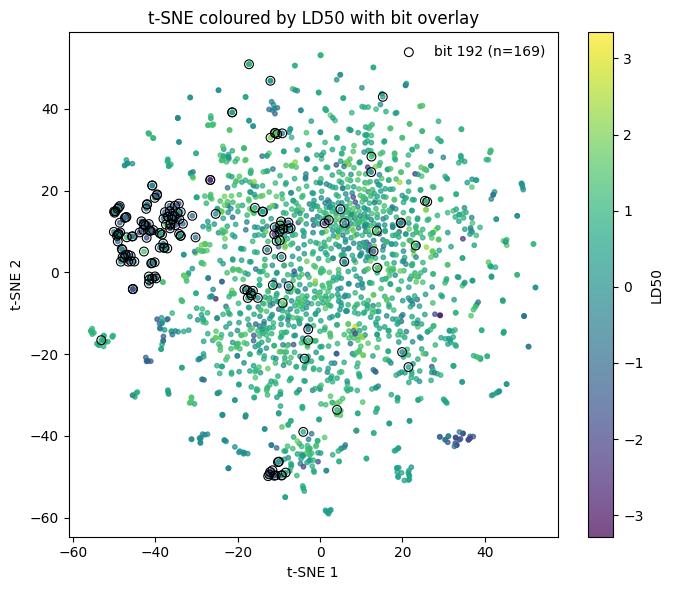

Enrichment relative to most toxic quartile:
 bit  192: Δmean(LD50)=-1.022 | tox-rate present=0.656 vs absent=0.213 | n_present=991, n_absent=10781


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- Choose the most correlated bit ---
b = int(np.argsort(-np.abs(corrs))[0])   

mask = FP[idx, b].astype(bool)

# --- Plot: t-SNE coloured by LD50 with bit overlay ---
fig, ax = plt.subplots(figsize=(7,6))
sc = ax.scatter(FP_embedded[:,0], FP_embedded[:,1], 
                c=y[idx], s=10, alpha=0.7, cmap="viridis")
ax.scatter(FP_embedded[mask,0], FP_embedded[mask,1],
           s=40, facecolors='none', edgecolors='black', linewidths=0.8,
           label=f'bit {b} (n={mask.sum()})')
plt.colorbar(sc, ax=ax, label="LD50")
ax.legend(frameon=False)
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE coloured by LD50 with bit overlay")
plt.tight_layout()
plt.show()

def bit_enrichment_simple(ld50, bit_vec, q=0.25):
    bit_vec = np.asarray(bit_vec).astype(bool)
    thr = np.quantile(ld50, q)
    toxic = ld50 <= thr
    mean_diff = ld50[bit_vec].mean() - ld50[~bit_vec].mean()
    tox_rate_present = toxic[bit_vec].mean() if bit_vec.any() else np.nan
    tox_rate_absent  = toxic[~bit_vec].mean() if (~bit_vec).any() else np.nan
    return dict(
        mean_diff=mean_diff,
        tox_rate_present=tox_rate_present,
        tox_rate_absent=tox_rate_absent,
        n_present=int(bit_vec.sum()),
        n_absent=int((~bit_vec).sum()),
        thr=float(thr)
    )

print("Enrichment relative to most toxic quartile:")
res = bit_enrichment_simple(y, FP[:, b], q=0.25)
print(f" bit {b:4d}: Δmean(LD50)={res['mean_diff']:.3f} | "
      f"tox-rate present={res['tox_rate_present']:.3f} vs absent={res['tox_rate_absent']:.3f} | "
      f"n_present={res['n_present']}, n_absent={res['n_absent']}")


/home3/slsr63/myjupyterenv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home3/slsr63/myjupyterenv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


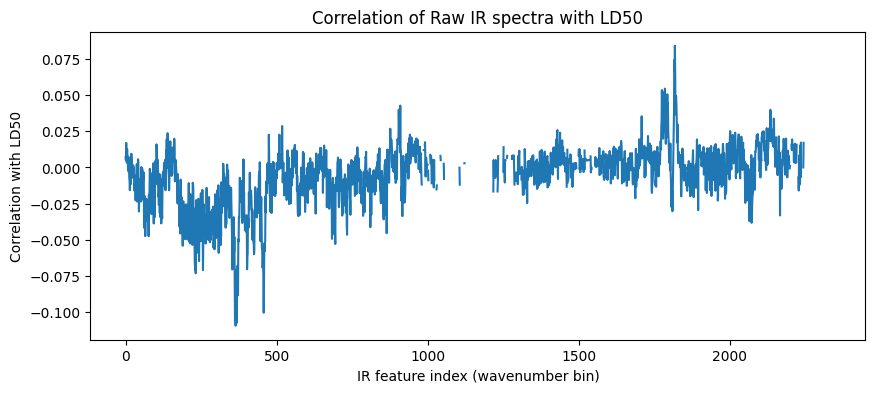

In [9]:
#Correlation check between raw IR and LD50

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

correlations = [np.corrcoef(IR[:, i], y)[0, 1] for i in range(IR.shape[1])]

plt.figure(figsize=(10,4))
plt.plot(range(len(correlations)), correlations)
plt.xlabel("IR feature index (wavenumber bin)")
plt.ylabel("Correlation with LD50")
plt.title("Correlation of Raw IR spectra with LD50")
plt.show()

In [8]:
#=====SVR======

In [3]:
#SVR-IR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- Baseline model on validation ---
from sklearn.pipeline import make_pipeline
baseline = make_pipeline(StandardScaler(), SVR())
baseline.fit(IR_tr, y_tr)
val_pred = baseline.predict(IR_val)
print("Baseline Val -> R2=%.4f MAE=%.4f RMSE=%.4f" % (
    r2_score(y_val, val_pred),
    mean_absolute_error(y_val, val_pred),
    mean_squared_error(y_val, val_pred)
))

Baseline Val -> R2=0.1955 MAE=0.5728 RMSE=0.6087


In [9]:
# === Efficient SVR(RBF) hyperparameter tuning for large IR ===
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import loguniform, uniform

# Successive halving
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV

IR_tr  = np.nan_to_num(IR_tr.astype(np.float32),  nan=0.0, posinf=0.0, neginf=0.0)
IR_val = np.nan_to_num(IR_val.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
y_tr   = y_tr.astype(np.float32)
y_val  = y_val.astype(np.float32)

pipe = make_pipeline(
    StandardScaler(with_mean=True, with_std=True),
    SVR(kernel="rbf", gamma="scale", cache_size=2000)
)

param_dist = {
    "svr__C": loguniform(1e-1, 1e2),     
    "svr__epsilon": uniform(1e-3, 0.3),  
}

halving = HalvingRandomSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    factor=3,                              
    resource="n_samples",                 
    max_resources=IR_tr.shape[0],
    min_resources=max(256, int(0.1*IR_tr.shape[0])),  
    cv=3,                                  
    n_candidates="exhaust",               
    n_jobs=-1,
    scoring="r2",
    random_state=42,
    verbose=1,
    refit=True
)

# Tune on TRAIN only
halving.fit(IR_tr, y_tr)

print("Best params:", halving.best_params_)
print("Best CV R2: %.4f" % halving.best_score_)


n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 824
max_resources_: 8240
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 10
n_resources: 824
Fitting 3 folds for each of 10 candidates, totalling 30 fits
----------
iter: 1
n_candidates: 4
n_resources: 2472
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 2
n_candidates: 2
n_resources: 7416
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best params: {'svr__C': np.float64(1.3292918943162166), 'svr__epsilon': np.float64(0.2862142919229748)}
Best CV R2: 0.1631


In [11]:
best_model = halving.best_estimator_   # scaler + SVR in a single pipeline

# === Validate the tuned model on VAL  ===
y_pred_val = best_model.predict(IR_val)
r2   = r2_score(y_val, y_pred_val)
mae  = mean_absolute_error(y_val, y_pred_val)
rmse = mean_squared_error(y_val, y_pred_val)
print("\n=== Tuned SVR on Validation ===")
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")


=== Tuned SVR on Validation ===
R2   : 0.2074
MAE  : 0.5782
RMSE : 0.5997


In [2]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Combine train+val
X_trainval = np.vstack([IR_tr, IR_val])
y_trainval = np.concatenate([y_tr, y_val])

# Build final model with best hyperparams
final_model = make_pipeline(
    StandardScaler(),
    SVR(kernel="rbf", gamma="scale", C=1.3293, epsilon=0.2862, cache_size=2000)
)

# Fit on train+val
final_model.fit(X_trainval, y_trainval)

,steps,"[('standardscaler', ...), ('svr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0


In [3]:
# Evaluate on test
y_pred_test = final_model.predict(IR_te)

r2   = r2_score(y_te, y_pred_test)
mae  = mean_absolute_error(y_te, y_pred_test)
rmse = mean_squared_error(y_te, y_pred_test)

print("\n=== Final SVR (RBF) on Test ===")
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")



=== Final SVR (RBF) on Test ===
R2   : 0.2007
MAE  : 0.5758
RMSE : 0.5722


In [9]:
import numpy as np
from sklearn.svm import LinearSVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

FP_tr  = np.nan_to_num(FP_tr.astype(np.float32),  nan=0.0, posinf=0.0, neginf=0.0)
FP_val = np.nan_to_num(FP_val.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
FP_te  = np.nan_to_num(FP_te.astype(np.float32),  nan=0.0, posinf=0.0, neginf=0.0)

y_tr  = y_tr.astype(np.float32)
y_val = y_val.astype(np.float32)
y_te  = y_te.astype(np.float32)

# --- 1) Train on TRAIN, evaluate on VAL ---
lin_svr = LinearSVR(
    C=1.0,
    epsilon=0.1,
    max_iter=20000,
    random_state=42
)

lin_svr.fit(FP_tr, y_tr)

y_pred_val = lin_svr.predict(FP_val)
r2_val  = r2_score(y_val, y_pred_val)
mae_val = mean_absolute_error(y_val, y_pred_val)
rmse_val = mean_squared_error(y_val, y_pred_val)

print("\n=== Linear SVR on ECFP (Validation) ===")
print(f"R2   : {r2_val:.4f}")
print(f"MAE  : {mae_val:.4f}")
print(f"RMSE : {rmse_val:.4f}")


=== Linear SVR on ECFP (Validation) ===
R2   : 0.3761
MAE  : 0.5100
RMSE : 0.4720


In [10]:
# --- 2) Retrain on TRAIN+VAL with same hyperparams, evaluate on TEST ---
X_trainval = np.vstack([FP_tr, FP_val])
y_trainval = np.concatenate([y_tr, y_val])

final_lin_svr = LinearSVR(
    C=1.0,
    epsilon=0.1,
    max_iter=20000,
    random_state=42
)
final_lin_svr.fit(X_trainval, y_trainval)

y_pred_test = final_lin_svr.predict(FP_te)
r2_te  = r2_score(y_te, y_pred_test)
mae_te = mean_absolute_error(y_te, y_pred_test)
rmse_te = mean_squared_error(y_te, y_pred_test)

print("\n=== Linear SVR on ECFP (Test) ===")
print(f"R2   : {r2_te:.4f}")
print(f"MAE  : {mae_te:.4f}")
print(f"RMSE : {rmse_te:.4f}")



=== Linear SVR on ECFP (Test) ===
R2   : 0.3477
MAE  : 0.4986
RMSE : 0.4670


#=====XGB=====

In [3]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone
from xgboost import XGBRegressor
import joblib

In [29]:
# --- IR-only XGB pipeline ---
ir_xgb_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("var", VarianceThreshold(0.0)),   # drop constant features
    ("scaler", StandardScaler()),      # trees don't need scaling, but harmless
    ("xgb", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    ))
])

# ---------- 1) Train -> Validate ----------
model_val = clone(ir_xgb_pipe)
model_val.fit(IR_tr, y_tr)

y_pred_val = model_val.predict(IR_val)
mae_val  = mean_absolute_error(y_val, y_pred_val)
rmse_val = mean_squared_error(y_val, y_pred_val)
r2_val   = r2_score(y_val, y_pred_val)

print("\nIR-only XGB (Validation)")
print(f"  MAE : {mae_val:.4f}")
print(f"  RMSE: {rmse_val:.4f}")
print(f"  R^2 : {r_val:.4f}" if (r_val:=r2_val) or True else "")


IR-only XGB (Validation)
  MAE : 0.5500
  RMSE: 0.5360
  R^2 : 0.2915


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

# 1) Build preprocessor (everything except XGB)
preproc = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("var", VarianceThreshold(0.0)),
])

# 2) Fit on train; transform train and val with the SAME fitted preproc
X_tr_t = preproc.fit_transform(IR_tr, y_tr)   
X_val_t = preproc.transform(IR_val)

# 3) Fit XGB with early stopping on the *transformed* arrays
xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=5000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    eval_metric="rmse"
)

xgb.fit(
    X_tr_t, y_tr,
    eval_set=[(X_val_t, y_val)],
    early_stopping_rounds=200,
    verbose=False
)

print(xgb.best_iteration, xgb.best_score)

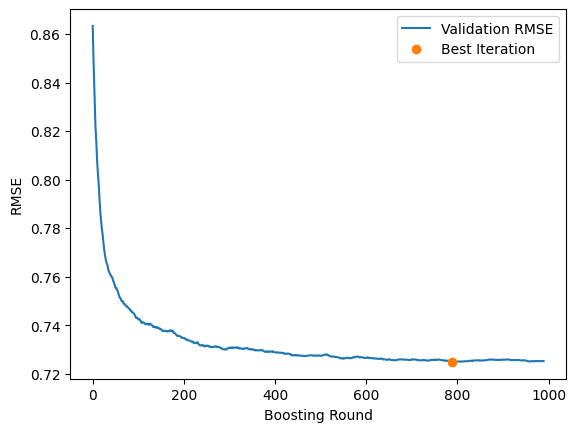

In [12]:
results = xgb.evals_result()
import matplotlib.pyplot as plt

plt.plot(results['validation_0']['rmse'], label='Validation RMSE')
plt.plot(results['validation_0']['rmse'], 'o', markevery=[xgb.best_iteration], label='Best Iteration')
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.legend()
plt.show()

In [ ]:
import itertools, random
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

space = {
    "learning_rate": [0.03, 0.05, 0.08],
    "max_depth": [4, 6, 8],
    "min_child_weight": [1, 3, 6],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "reg_alpha": [0.0, 0.1],
    "reg_lambda": [1.0, 10.0],
}

def sample_param(space):
    return {k: random.choice(v) for k, v in space.items()}

best = {"rmse": np.inf, "params": None, "iter": None}

for i in range(24):  # try ~24 configs; increase to 32 if still quick
    params = sample_param(space)
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        tree_method="hist",
        n_jobs=-1,
        eval_metric="rmse",
        random_state=42,
        **params
    )
    model.fit(
        X_tr_t, y_tr,
        eval_set=[(X_val_t, y_val)],
        early_stopping_rounds=100,
        verbose=False
    )
    y_pred = model.predict(X_val_t)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    if rmse < best["rmse"]:
        best = {"rmse": rmse, "params": params, "iter": model.best_iteration}

print("Best RMSE:", best["rmse"])
print("Best params:", best["params"])
print("Best iteration:", best["iter"])

/home3/slsr63/myjupyterenv/lib/python3.10/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/home3/slsr63/myjupyterenv/lib/python3.10/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/home3/slsr63/myjupyterenv/lib/python3.10/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/home3/slsr63/myjupyterenv/lib/python3.10/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility wit

In [14]:
# 1. Fit preprocessor on training set
preproc = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("var", VarianceThreshold(0.0)),
])
X_tr_t = preproc.fit_transform(IR_tr, y_tr)
X_val_t = preproc.transform(IR_val)

# 2. Define XGB
xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=5000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    eval_metric="rmse",
)

# 3. Train with early stopping
xgb.fit(
    X_tr_t, y_tr,
    eval_set=[(X_val_t, y_val)],
    early_stopping_rounds=200,
    verbose=False
)

print("Best iteration:", xgb.best_iteration)
print("Best RMSE:", xgb.best_score)


/home3/slsr63/myjupyterenv/lib/python3.10/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


Best iteration: 789
Best RMSE: 0.724856391917931


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- 1) Merge train + val ----
IR_trval = np.vstack([IR_tr, IR_val])
y_trval  = np.concatenate([y_tr, y_val])

# ---- 2) Final pipeline ----
final_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("var", VarianceThreshold(0.0)),
    ("scaler", StandardScaler()),
    ("xgb", XGBRegressor(
        n_estimators=1331,    # from best_iteration
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=3,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=0.0,
        reg_lambda=10.0,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

# ---- 3) Fit on all train+val ----
final_pipe.fit(IR_trval, y_trval)

#best parameters 
# ---- 4) Test evaluation ----
y_pred_test = final_pipe.predict(IR_te)
mae  = mean_absolute_error(y_te, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_te, y_pred_test))
r2   = r2_score(y_te, y_pred_test)

print("IR-only XGB (Test)")
print(f"  MAE : {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R^2 : {r2:.4f}")


NameError: name 'IR_test' is not defined

In [11]:
#====XGB-ECFP====
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone
from xgboost import XGBRegressor

# --- ECFP-only XGB pipeline ---
ecfp_xgb_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),  
    ("var", VarianceThreshold(0.0)),                   
    ("xgb", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,            
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    ))
])

# ---------- 1) Train -> Validate ----------
model_val = clone(ecfp_xgb_pipe)
model_val.fit(FP_tr, y_tr)

y_pred_val = model_val.predict(FP_val)
mae_val  = mean_absolute_error(y_val, y_pred_val)
rmse_val = mean_squared_error(y_val, y_pred_val)
r2_val   = r2_score(y_val, y_pred_val)

print("\nECFP-only XGB (Validation)")
print(f"  MAE : {mae_val:.4f}")
print(f"  RMSE: {rmse_val:.4f}")
print(f"  R^2 : {r2_val:.4f}")


ECFP-only XGB (Validation)
  MAE : 0.4174
  RMSE: 0.3193
  R^2 : 0.5779


/home3/slsr63/myjupyterenv/lib/python3.10/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/home3/slsr63/myjupyterenv/lib/python3.10/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/home3/slsr63/myjupyterenv/lib/python3.10/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/home3/slsr63/myjupyterenv/lib/python3.10/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility wit

=== ECFP XGB (Validation) — Best over random search ===
Best RMSE : 0.5439
Best MAE  : 0.4014
Best R^2  : 0.6090
Best iter : 3210
Best params: {'learning_rate': 0.03, 'max_depth': 12, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.5, 'reg_alpha': 0.0, 'reg_lambda': 10.0}


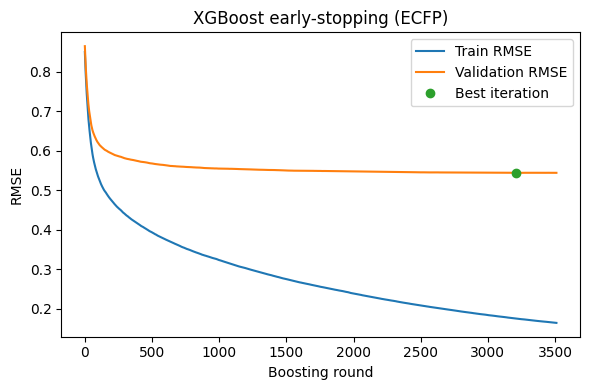

In [9]:
##plot and get the best parammeter 

# === Random search + early stopping + learning-curve plot (ECFP) ===
import random, numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# 0) Preprocessor for ECFP (0/1 bits)
ecfp_preproc = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),  
    ("var", VarianceThreshold(0.0)),                   
])

# Fit on TRAIN only; transform TRAIN and VAL the same way
X_tr_t  = ecfp_preproc.fit_transform(FP_tr)
X_val_t = ecfp_preproc.transform(FP_val)

# 1) Random search space (tuned for sparse/binary ECFP)
space = {
    "learning_rate":    [0.02, 0.03, 0.05, 0.08, 0.10],
    "max_depth":        [4, 6, 8, 10, 12],
    "min_child_weight": [1, 3, 6, 10],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.9, 1.0],
    "reg_alpha":        [0.0, 0.1, 0.5, 1.0],
    "reg_lambda":       [1.0, 5.0, 10.0, 20.0],
}

def sample_param(space):
    return {k: random.choice(v) for k, v in space.items()}

best = {"rmse": np.inf, "params": None, "iter": None, "model": None,
        "mae": None, "r2": None}

# 2) Random search with early stopping (validation is last in eval_set)
for _ in range(32):  # increase to 64 if still fast
    params = sample_param(space)
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=6000,           
        tree_method="hist",
        n_jobs=-1,
        eval_metric="rmse",
        random_state=42,
        **params
    )
    model.fit(
        X_tr_t, y_tr,
        eval_set=[(X_tr_t, y_tr), (X_val_t, y_val)],  
        early_stopping_rounds=300,
        verbose=False
    )
    y_pred = model.predict(X_val_t)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    if rmse < best["rmse"]:
        best.update({
            "rmse": rmse,
            "params": params,
            "iter": model.best_iteration,
            "model": model,
            "mae": mean_absolute_error(y_val, y_pred),
            "r2": r2_score(y_val, y_pred),
        })

print("=== ECFP XGB (Validation) — Best over random search ===")
print(f"Best RMSE : {best['rmse']:.4f}")
print(f"Best MAE  : {best['mae']:.4f}")
print(f"Best R^2  : {best['r2']:.4f}")
print(f"Best iter : {best['iter']}")
print("Best params:", best["params"])

# 3) Plot & save the early-stopping learning curve for the BEST run
results = best["model"].evals_result()
val_curve   = results['validation_1']['rmse']

plt.figure(figsize=(6, 4))
plt.plot(val_curve,   label="Validation RMSE")
plt.plot(best["iter"], val_curve[best["iter"]], 'o', label="Best iteration")
plt.xlabel("Boosting round")
plt.ylabel("RMSE")
plt.title("XGBoost early-stopping (ECFP)")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# ---------- 2) Train+Val -> Test ----------
X_trainval = np.vstack([FP_tr, FP_val])
y_trainval = np.concatenate([y_tr, y_val])

model_test = clone(ecfp_xgb_pipe)
model_test.fit(X_trainval, y_trainval)

y_pred_test = model_test.predict(FP_te)
mae_te  = mean_absolute_error(y_te, y_pred_test)
rmse_te = mean_squared_error(y_te, y_pred_test)
r2_te   = r2_score(y_te, y_pred_test)

print("\nECFP-only XGB (Test)")
print(f"  MAE : {mae_te:.4f}")
print(f"  RMSE: {rmse_te:.4f}")
print(f"  R^2 : {r2_te:.4f}")


ECFP-only XGB (Test)
  MAE : 0.4117
  RMSE: 0.3145
  R^2 : 0.5607


#====CNN=====#

In [16]:
#===early fusion===
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import layers, models, callbacks, regularizers


2025-09-03 20:32:41.558064: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-03 20:32:41.567128: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-03 20:32:41.575763: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-03 20:32:41.597668: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756927961.631293  785596 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756927961.63

In [5]:
# ---- 2) Scale IR only (fit on train) ----
ir_scaler = StandardScaler()
IR_tr_s  = ir_scaler.fit_transform(IR_tr)
IR_val_s = ir_scaler.transform(IR_val)
IR_te_s  = ir_scaler.transform(IR_te)

# ---- 3) Early-fusion inputs (concat IR||ECFP) ----
X_tr_early  = np.concatenate([IR_tr_s,  FP_tr],  axis=1)
X_val_early = np.concatenate([IR_val_s, FP_val], axis=1)
X_te_early  = np.concatenate([IR_te_s,  FP_te],  axis=1)

seq_len = X_tr_early.shape[1]


In [5]:
#option 2
# -----------------------------
# Early-fusion inputs (concat IR||ECFP) without scaling
# -----------------------------
X_train_early = np.concatenate([IR_tr, FP_tr], axis=1)
X_val_early = np.concatenate([IR_val, FP_val], axis=1)
X_test_early = np.concatenate([IR_te, FP_te], axis=1)

# Determine the sequence length (number of features after concatenation)
seq_len = X_train_early.shape[1]

# Reshape to (samples, timesteps, channels)
X_train_cnn = X_train_early[..., np.newaxis]
X_val_cnn = X_val_early[..., np.newaxis]
X_test_cnn = X_test_early[..., np.newaxis]


In [ ]:
# -----------------------------
# CNN model definition
# -----------------------------
def cnn_model(input_len):
    reg = regularizers.l2(1e-5)
    inp = layers.Input(shape=(input_len, 1))

    x = layers.Conv1D(64, kernel_size=17, padding="same",
                      activation=None, kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.1)(x)

    for d in [2, 4, 8]:
        skip = x
        x = layers.Conv1D(64, kernel_size=17, padding="same", dilation_rate=d,
                          activation=None, kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Conv1D(64, kernel_size=1, padding="same",
                          activation=None, kernel_regularizer=reg)(x)
        x = layers.Add()([x, skip])
        x = layers.Activation("relu")(x)
        x = layers.Dropout(0.1)(x)

    x = layers.Conv1D(128, kernel_size=33, padding="same", activation="relu",
                      kernel_regularizer=reg)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=reg)(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1)(x)  

    model = models.Model(inp, out)
    opt = tf.keras.optimizers.Adam(learning_rate=3e-4)
    model.compile(optimizer=opt, loss=tf.keras.losses.Huber(delta=1.0))
    return model

# -----------------------------
# Train model
# -----------------------------
model = cnn_model(X_train_cnn.shape[1])
model.summary()

cbs = [
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=5, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor="val_loss", patience=12,
                            restore_best_weights=True, verbose=1)
]

y_train_std, y_val_std, y_test_std = y_tr, y_val, y_te 

hist = model.fit(
    X_train_cnn, y_train_std,
    validation_data=(X_val_cnn, y_val_std),
    epochs=120,
    batch_size=64,
    callbacks=cbs,
    verbose=1
)

# -----------------------------
# Evaluate
# -----------------------------
y_pred_std = model.predict(X_test_cnn, verbose=0).ravel()

# Calculate metrics
mae = mean_absolute_error(y_test_std, y_pred_std)
rmse = np.sqrt(mean_squared_error(y_test_std, y_pred_std))
r2 = r2_score(y_test_std, y_pred_std)

print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 4583, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 4583, 64)  │      1,152 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4583, 64)  │        256 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 4583, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 4583, 64)  │          0 │ activation_7[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 4583, 64)  │     69,696 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4583, 64)  │        256 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 4583, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 4583, 64)  │      4,160 │ activation_8[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 4583, 64)  │          0 │ conv1d_10[0][0],  │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 4583, 64)  │          0 │ add_3[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 4583, 64)  │          0 │ activation_9[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 4583, 64)  │     69,696 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4583, 64)  │        256 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 4583, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 4583, 64)  │      4,160 │ activation_10[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 4583, 64)  │          0 │ conv1d_12[0][0],  │
│                     │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 4583, 64)  │          0 │ add_4[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 4583, 64)  │          0 │ activation_11[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 510,849 (1.95 MB)

 Trainable params: 510,337 (1.95 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1034s 8s/step - loss: 0.3162 - val_loss: 0.3130 - learning_rate: 3.0000e-04
Epoch 2/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1030s 8s/step - loss: 0.3068 - val_loss: 0.3069 - learning_rate: 3.0000e-04
Epoch 3/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1030s 8s/step - loss: 0.3015 - val_loss: 0.3040 - learning_rate: 3.0000e-04
Epoch 4/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.2969

In [11]:
from tensorflow.keras import layers, models, callbacks, regularizers
import tensorflow as tf
from sklearn.metrics import r2_score, mean_squared_error

# -----------------------------
# CNN model definition
# -----------------------------
def cnn_model(input_len):
    reg = regularizers.l2(1e-5)
    inp = layers.Input(shape=(input_len, 1))

    x = layers.Conv1D(64, kernel_size=17, padding="same",
                      activation=None, kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.1)(x)

    for d in [2, 4, 8]:
        skip = x
        x = layers.Conv1D(64, kernel_size=17, padding="same", dilation_rate=d,
                          activation=None, kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Conv1D(64, kernel_size=1, padding="same",
                          activation=None, kernel_regularizer=reg)(x)
        x = layers.Add()([x, skip])
        x = layers.Activation("relu")(x)
        x = layers.Dropout(0.1)(x)

    x = layers.Conv1D(128, kernel_size=33, padding="same", activation="relu",
                      kernel_regularizer=reg)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=reg)(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1)(x)  

    model = models.Model(inp, out)
    opt = tf.keras.optimizers.Adam(learning_rate=3e-4)
    model.compile(optimizer=opt, loss=tf.keras.losses.Huber(delta=1.0))
    return model

# -----------------------------
# Prepare inputs for CNN
# -----------------------------
# Reshape to (samples, timesteps, channels)
X_tr_cnn = X_tr_early[..., np.newaxis]
X_val_cnn = X_val_early[..., np.newaxis]
X_te_cnn = X_te_early[..., np.newaxis]

# If you are standardizing y, do it here:
y_tr_s, y_val_s, y_te_s = y_tr, y_val, y_te

# -----------------------------
# Train model
# -----------------------------
model = cnn_model(X_tr_cnn.shape[1])
model.summary()

cbs = [
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=5, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor="val_loss", patience=12,
                            restore_best_weights=True, verbose=1)
]

hist = model.fit(
    X_tr_cnn, y_tr_s,
    validation_data=(X_val_cnn, y_val_s),
    epochs=120,
    batch_size=64,
    callbacks=cbs,
    verbose=1
)

# -----------------------------
# Evaluate
# -----------------------------
y_pred_std = model.predict(X_te_cnn, verbose=0).ravel()


E0000 00:00:1756465694.013410  468242 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1756465694.016341  468242 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 4583, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 4583, 64)  │      1,152 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 4583, 64)  │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 4583, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4583, 64)  │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 4583, 64)  │     69,696 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4583, 64)  │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 4583, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 4583, 64)  │      4,160 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 4583, 64)  │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 4583, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 4583, 64)  │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 4583, 64)  │     69,696 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4583, 64)  │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 4583, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 4583, 64)  │      4,160 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 4583, 64)  │          0 │ conv1d_4[0][0],   │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 4583, 64)  │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 4583, 64)  │          0 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 510,849 (1.95 MB)

 Trainable params: 510,337 (1.95 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1958s 15s/step - loss: 0.3135 - val_loss: 0.3141 - learning_rate: 3.0000e-04
Epoch 2/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1999s 15s/step - loss: 0.3010 - val_loss: 0.3883 - learning_rate: 3.0000e-04
Epoch 3/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1999s 15s/step - loss: 0.2943 - val_loss: 0.3049 - learning_rate: 3.0000e-04
Epoch 4/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1904s 15s/step - loss: 0.2913 - val_loss: 0.3243 - learning_rate: 3.0000e-04
Epoch 5/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1999s 15s/step - loss: 0.2824 - val_loss: 0.3178 - learning_rate: 3.0000e-04
Epoch 6/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1978s 15s/step - loss: 0.2759 - val_loss: 0.3122 - learning_rate: 3.0000e-04
Epoch 7/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1984s 15s/step - loss: 0.2704 - val_loss: 0.2894 - learning_rate: 3.0000e-04
Epoch 8/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 2040s 16s/step - loss: 0.2675 - val_loss: 0.3009 - learning_rate: 3.0000e-04
Epoch 9/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1078s 8s/step -

In [1]:
r2 = r2_score(y_te, y_pred_std)
rmse = mean_squared_error(y_te, y_pred_std)
print(f"\nCNN (dilated early-fusion) on IR+ECFP")
print(f"  R2   : {r2:.4f}")
print(f"  RMSE : {rmse:.4f}")

NameError: name 'r2_score' is not defined

In [13]:
#====late fusion====
import numpy as np
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers

2025-09-02 23:42:46.877711: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-02 23:42:46.880931: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-02 23:42:46.884754: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-02 23:42:46.893983: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756852966.909197  196200 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756852966.91

In [14]:
# Convert to float32 and reshape IR for Conv1D
X_ir_tr = IR_tr.astype('float32')[..., None]   # (N, L, 1)
X_ir_val = IR_val.astype('float32')[..., None]
X_ir_te = IR_te.astype('float32')[..., None]

X_fp_tr = FP_tr.astype('float32')              # (N, n_bits)
X_fp_val = FP_val.astype('float32')
X_fp_te = FP_te.astype('float32')

y_tr_ = y_tr.astype('float32')
y_val_ = y_val.astype('float32')
y_te_ = y_te.astype('float32')

# Simple 2-branch model
ir_in = keras.Input(shape=(X_ir_tr.shape[1], 1), name='ir')
x = layers.Conv1D(64, 9, padding='same', activation='relu')(ir_in)
x = layers.MaxPool1D(2)(x)
x = layers.Conv1D(128, 7, padding='same', activation='relu')(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
ir_repr = layers.LayerNormalization()(x)

fp_in = keras.Input(shape=(X_fp_tr.shape[1],), name='ecfp')
y_in = layers.BatchNormalization()(fp_in)       # handles 0/1 scale
y_in = layers.Dense(512, activation='relu')(y_in)
y_in = layers.Dropout(0.3)(y_in)
y_in = layers.Dense(256, activation='relu')(y_in)
fp_repr = layers.LayerNormalization()(y_in)

z = layers.Concatenate()([ir_repr, fp_repr])
z = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(z)
z = layers.Dropout(0.3)(z)
z = layers.Dense(128, activation='relu')(z)
out = layers.Dense(1)(z)

model = keras.Model(inputs=[ir_in, fp_in], outputs=out)
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='mse',
              metrics=[keras.metrics.MeanAbsoluteError(name='mae')])


E0000 00:00:1756852976.714608  196200 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1756852976.717201  196200 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [15]:
# Train the model
hist = model.fit(
    {'ir': X_ir_tr, 'ecfp': X_fp_tr}, y_tr_,
    validation_data=({'ir': X_ir_val, 'ecfp': X_fp_val}, y_val_),
    epochs=20, batch_size=64,
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)


Epoch 1/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 36s 261ms/step - loss: 0.6938 - mae: 0.6138 - val_loss: 0.4762 - val_mae: 0.5078
Epoch 2/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 33s 258ms/step - loss: 0.4007 - mae: 0.4568 - val_loss: 0.4368 - val_mae: 0.4830
Epoch 3/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 33s 258ms/step - loss: 0.3158 - mae: 0.4043 - val_loss: 0.4142 - val_mae: 0.4676
Epoch 4/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 33s 258ms/step - loss: 0.2559 - mae: 0.3586 - val_loss: 0.4131 - val_mae: 0.4729
Epoch 5/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 33s 259ms/step - loss: 0.2103 - mae: 0.3213 - val_loss: 0.4193 - val_mae: 0.4784
Epoch 6/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 33s 258ms/step - loss: 0.1796 - mae: 0.2918 - val_loss: 0.4602 - val_mae: 0.5119
Epoch 7/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 33s 257ms/step - loss: 0.1505 - mae: 0.2663 - val_loss: 0.4500 - val_mae: 0.5042
Epoch 8/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 33s 257ms/step - loss: 0.1344 - mae: 0.2487 - val_loss: 0.4759 - val_mae: 0.5233
Epoch 9/20
129/129 ━━━━━━━━━━━━━

In [5]:
from sklearn.metrics import r2_score

y_pred = model.predict({'ir': X_ir_te, 'ecfp': X_fp_te})
r2 = r2_score(y_te_, y_pred)
test_loss, test_mae = model.evaluate(
    {'ir': X_ir_te, 'ecfp': X_fp_te}, y_te_,
    batch_size=64
)

print(f'Test Loss: {test_loss}')
print(f'Test Mean Absolute Error (MAE): {test_mae}')
print(f'R² Score: {r2}')


56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - loss: 0.3899 - mae: 0.4482
Test Loss: 0.38985732197761536
Test Mean Absolute Error (MAE): 0.4482489228248596
R² Score: 0.4979779124259949


In [16]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_tr_pred = model.predict({'ir': X_ir_tr, 'ecfp': X_fp_tr}, verbose=0).squeeze()

train_mae  = mean_absolute_error(y_tr_, y_tr_pred)
train_rmse = np.sqrt(mean_squared_error(y_tr_, y_tr_pred))
train_r2   = r2_score(y_tr_, y_tr_pred)

print(f"Train MAE : {train_mae:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Train R^2 : {train_r2:.4f}")

Train MAE : 0.3069
Train RMSE: 0.3961
Train R^2 : 0.7858


In [ ]:
# =========================
# Train on STANDARDISED target (better optimisation), then invert for metrics
# =========================
y_mu, y_sigma = y_tr_.mean(), y_tr_.std() + 1e-8
y_tr_z  = (y_tr_  - y_mu) / y_sigma
y_val_z = (y_val_ - y_mu) / y_sigma
y_te_z  = (y_te_  - y_mu) / y_sigma

# =========================
# Build model (regularised late fusion + wide linear path)
# =========================
L2 = 5e-4  
LR = 1e-3

# IR branch
ir_in = keras.Input(shape=(X_ir_tr.shape[1], 1), name='ir')
x = layers.GaussianNoise(0.01)(ir_in)  # tiny train-time noise

x = layers.Conv1D(64, 7, padding='same', use_bias=False,
                  kernel_regularizer=regularizers.l2(L2))(x)
x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
x = layers.MaxPool1D(2)(x)
x = layers.SpatialDropout1D(0.10)(x)  

x = layers.Conv1D(64, 7, padding='same', use_bias=False,
                  kernel_regularizer=regularizers.l2(L2))(x)
x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
x = layers.MaxPool1D(2)(x)

x = layers.Conv1D(128, 5, padding='same', use_bias=False,
                  kernel_regularizer=regularizers.l2(L2))(x)
x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(L2))(x)
x = layers.Dropout(0.30)(x)
ir_repr = layers.LayerNormalization()(x)

# FP branch (deep)
fp_in = keras.Input(shape=(X_fp_tr.shape[1],), name='ecfp')
y = layers.BatchNormalization()(fp_in)
y = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(L2))(y)
y = layers.Dropout(0.35)(y)
y = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(L2))(y)
fp_repr = layers.LayerNormalization()(y)

# Deep fusion head
z = layers.Concatenate()([ir_repr, fp_repr])
z = layers.LayerNormalization()(z)
z = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(L2))(z)
z = layers.Dropout(0.35)(z)
z = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(L2))(z)
deep_out = layers.Dense(1)(z)

# Wide linear path on RAW ECFP (ridge-like)
wide_out = layers.Dense(1, use_bias=False, kernel_regularizer=regularizers.l2(1e-3))(fp_in)

# Combine (residual-style)
out = layers.Add()([deep_out, wide_out])

model = keras.Model(inputs=[ir_in, fp_in], outputs=out)

# Optimiser: AdamW (decoupled weight decay) with fallback
try:
    opt = keras.optimizers.AdamW(learning_rate=LR, weight_decay=2e-4, clipnorm=1.0)
except Exception:
    opt = keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0)

model.compile(optimizer=opt,
              loss=keras.losses.Huber(delta=0.5),
              metrics=[keras.metrics.MeanAbsoluteError(name='mae')])
model.summary()

# =========================
# Training
# =========================
cb = [
    callbacks.EarlyStopping(monitor='val_mae', mode='min', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_mae', mode='min', factor=0.5, patience=4,
                                min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_fusion.keras', monitor='val_mae', mode='min', save_best_only=True)
]

hist = model.fit(
    {'ir': X_ir_tr, 'ecfp': X_fp_tr}, y_tr_z,
    validation_data=({'ir': X_ir_val, 'ecfp': X_fp_val}, y_val_z),
    epochs=200, batch_size=64, callbacks=cb, verbose=1
)

# =========================
# Evaluation (invert target standardisation)
# =========================
def report(Xir, Xfp, y_true, name):
    y_pred_z = model.predict({'ir': Xir, 'ecfp': Xfp}, verbose=0).squeeze()
    y_pred   = y_pred_z * y_sigma + y_mu
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name:>5} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R^2: {r2:.4f}")

report(X_ir_tr,  X_fp_tr,  y_tr_,  "Train")
report(X_ir_val, X_fp_val, y_val_, " Val ")
report(X_ir_te,  X_fp_te,  y_te_,  "Test")

#====Tuning===

In [22]:
# =========================
# Train on STANDARDISED target (better optimisation), then invert for metrics
# =========================
y_mu, y_sigma = y_tr_.mean(), y_tr_.std() + 1e-8
y_tr_z  = (y_tr_  - y_mu) / y_sigma
y_val_z = (y_val_ - y_mu) / y_sigma
y_te_z  = (y_te_  - y_mu) / y_sigma

# =========================
# Build model (regularised late fusion + wide linear path)
# =========================
L2 = 5e-4  # a bit stronger than before
LR = 1e-3

# IR branch
ir_in = keras.Input(shape=(X_ir_tr.shape[1], 1), name='ir')
x = layers.GaussianNoise(0.01)(ir_in)  # tiny train-time noise

x = layers.Conv1D(64, 7, padding='same', use_bias=False,
                  kernel_regularizer=regularizers.l2(L2))(x)
x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
x = layers.MaxPool1D(2)(x)
x = layers.SpatialDropout1D(0.10)(x)  # drop whole feature maps (regularises)

x = layers.Conv1D(64, 7, padding='same', use_bias=False,
                  kernel_regularizer=regularizers.l2(L2))(x)
x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
x = layers.MaxPool1D(2)(x)

x = layers.Conv1D(128, 5, padding='same', use_bias=False,
                  kernel_regularizer=regularizers.l2(L2))(x)
x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(L2))(x)
x = layers.Dropout(0.30)(x)
ir_repr = layers.LayerNormalization()(x)

# FP branch (deep)
fp_in = keras.Input(shape=(X_fp_tr.shape[1],), name='ecfp')
y = layers.BatchNormalization()(fp_in)
y = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(L2))(y)
y = layers.Dropout(0.35)(y)
y = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(L2))(y)
fp_repr = layers.LayerNormalization()(y)

# Deep fusion head
z = layers.Concatenate()([ir_repr, fp_repr])
z = layers.LayerNormalization()(z)
z = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(L2))(z)
z = layers.Dropout(0.35)(z)
z = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(L2))(z)
deep_out = layers.Dense(1)(z)

# Wide linear path on RAW ECFP (ridge-like)
wide_out = layers.Dense(1, use_bias=False, kernel_regularizer=regularizers.l2(1e-3))(fp_in)

# Combine (residual-style)
out = layers.Add()([deep_out, wide_out])

model = keras.Model(inputs=[ir_in, fp_in], outputs=out)

# Optimiser: AdamW (decoupled weight decay) with fallback
try:
    opt = keras.optimizers.AdamW(learning_rate=LR, weight_decay=2e-4, clipnorm=1.0)
except Exception:
    opt = keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0)

model.compile(optimizer=opt,
              loss=keras.losses.Huber(delta=0.5),
              metrics=[keras.metrics.MeanAbsoluteError(name='mae')])
model.summary()

# =========================
# Training
# =========================
cb = [
    callbacks.EarlyStopping(monitor='val_mae', mode='min', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_mae', mode='min', factor=0.5, patience=4,
                                min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_fusion.keras', monitor='val_mae', mode='min', save_best_only=True)
]

hist = model.fit(
    {'ir': X_ir_tr, 'ecfp': X_fp_tr}, y_tr_z,
    validation_data=({'ir': X_ir_val, 'ecfp': X_fp_val}, y_val_z),
    epochs=200, batch_size=64, callbacks=cb, verbose=1
)

# =========================
# Evaluation (invert target standardisation)
# =========================
def report(Xir, Xfp, y_true, name):
    y_pred_z = model.predict({'ir': Xir, 'ecfp': Xfp}, verbose=0).squeeze()
    y_pred   = y_pred_z * y_sigma + y_mu
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name:>5} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R^2: {r2:.4f}")

report(X_ir_tr,  X_fp_tr,  y_tr_,  "Train")
report(X_ir_val, X_fp_val, y_val_, " Val ")
report(X_ir_te,  X_fp_te,  y_te_,  "Test")

E0000 00:00:1756928105.976456  785596 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1756928105.981154  785596 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ir (InputLayer)     │ (None, 2535, 1)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 2535, 1)   │          0 │ ir[0][0]          │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2535, 64)  │        448 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2535, 64)  │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 2535, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 1267, 64)  │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 1267, 64)  │          0 │ max_pooling1d[0]… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1267, 64)  │     28,672 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1267, 64)  │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 1267, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 633, 64)   │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 633, 128)  │     40,960 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 633, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ecfp (InputLayer)   │ (None, 2048)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 633, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2048)      │      8,192 │ ecfp[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ activation_2[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p

 Total params: 680,833 (2.60 MB)

 Trainable params: 676,225 (2.58 MB)

 Non-trainable params: 4,608 (18.00 KB)

Epoch 1/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 87s 590ms/step - loss: 0.6956 - mae: 0.6665 - val_loss: 0.5918 - val_mae: 0.5592 - learning_rate: 0.0010
Epoch 2/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 90s 657ms/step - loss: 0.5379 - mae: 0.5337 - val_loss: 0.4933 - val_mae: 0.5258 - learning_rate: 0.0010
Epoch 3/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 126s 537ms/step - loss: 0.4398 - mae: 0.4786 - val_loss: 0.4266 - val_mae: 0.5149 - learning_rate: 0.0010
Epoch 4/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 89s 590ms/step - loss: 0.3659 - mae: 0.4346 - val_loss: 0.3757 - val_mae: 0.5049 - learning_rate: 0.0010
Epoch 5/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 51s 397ms/step - loss: 0.3151 - mae: 0.4067 - val_loss: 0.3486 - val_mae: 0.5224 - learning_rate: 0.0010
Epoch 6/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 48s 369ms/step - loss: 0.2747 - mae: 0.3813 - val_loss: 0.3289 - val_mae: 0.5329 - learning_rate: 0.0010
Epoch 7/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 47s 368ms/step - loss: 0.2468 - mae: 0.3657 - val_loss: 0.3207 - val_mae: 0.5515 -